In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)


In [7]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Classes:",np.unique(y))

Dataset Shape: (569, 30)
Classes: [0 1]


In [40]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
mle_model = LogisticRegression(
    penalty=None,
    max_iter=5000,
    random_state=42
)

mle_model.fit(X_train,y_train)

y_pred_mle = mle_model.predict(X_test)

In [43]:
map_l2 = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)

map_l2.fit(X_train, y_train)

y_pred_l2 = map_l2.predict(X_test)

In [33]:
map_l1 = LogisticRegression(
    penalty='l1',
    C=1.0,
    solver='liblinear',
    max_iter=5000,
    random_state=42
)

map_l1.fit(X_train, y_train)

y_pred_l1 = map_l1.predict(X_test)

In [34]:
def evaluate(model_name, y_true, y_pred):
    print("\n", "="*40)
    print(model_name)
    print("="*40)

    print("Accuracy :",accuracy_score(y_true,y_pred))
    print("Precision:",precision_score(y_true,y_pred))
    print("Recall   :",recall_score(y_true,y_pred))
    print("F1 Score :",f1_score(y_true,y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true,y_pred))
    

In [35]:
evaluate("MLE", y_test, y_pred_mle)
evaluate("MAP (L2)", y_test, y_pred_l2)
evaluate("MAP (L1)", y_test, y_pred_l1)


MLE
Accuracy : 0.9385964912280702
Precision: 0.9848484848484849
Recall   : 0.9154929577464789
F1 Score : 0.948905109489051

Confusion Matrix
[[42  1]
 [ 6 65]]

MAP (L2)
Accuracy : 0.9736842105263158
Precision: 0.9722222222222222
Recall   : 0.9859154929577465
F1 Score : 0.9790209790209791

Confusion Matrix
[[41  2]
 [ 1 70]]

MAP (L1)
Accuracy : 0.9736842105263158
Precision: 0.9857142857142858
Recall   : 0.971830985915493
F1 Score : 0.9787234042553191

Confusion Matrix
[[42  1]
 [ 2 69]]


In [36]:
print("Number of Zero Coefficients")

print("MLE    :",np.sum(mle_model.coef_[0] == 0))

print("MAP L2 :",np.sum(map_l2.coef_[0] == 0))

print("MAP L1 :",np.sum(map_l1.coef_[0] == 0))

Number of Zero Coefficients
MLE    : 0
MAP L2 : 0
MAP L1 : 16


In [37]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])

models = [
    ("MLE",mle_model,y_pred_mle),
    ("MAP L2", map_l2,y_pred_l2),
    ("MAP L1",map_l1,y_pred_l1)
]

for name, model, pred in models:
    results.loc[len(results)] = [
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ]

print(results)

    Model  Accuracy  Precision    Recall  F1 Score
0     MLE  0.938596   0.984848  0.915493  0.948905
1  MAP L2  0.973684   0.972222  0.985915  0.979021
2  MAP L1  0.973684   0.985714  0.971831  0.978723


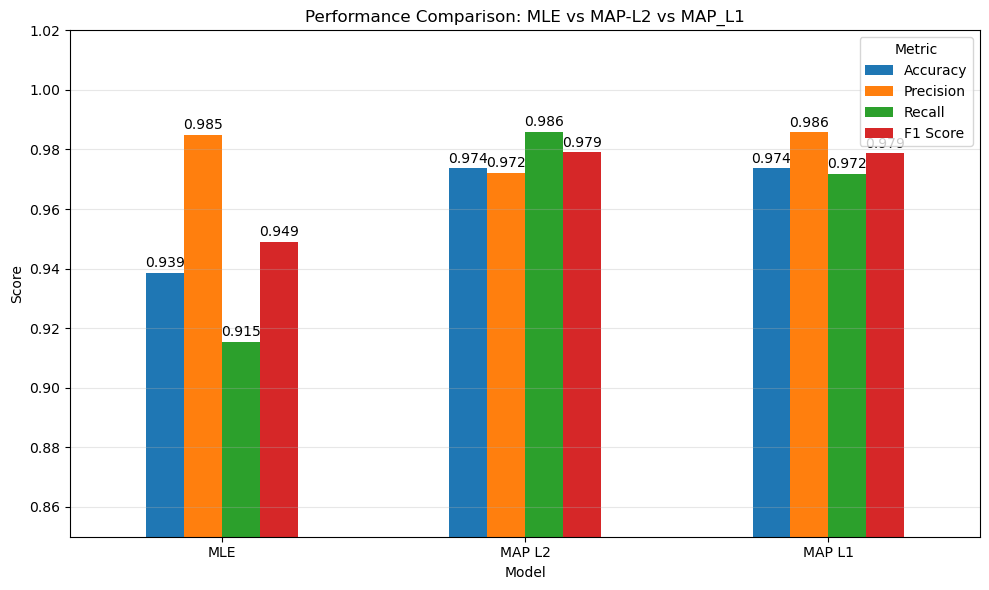

In [38]:
ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Performance Comparison: MLE vs MAP-L2 vs MAP_L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y",alpha=0.3)

for container in ax.containers:
    ax.bar_label(container,fmt="%.3f",padding=2)
plt.tight_layout()
plt.show()

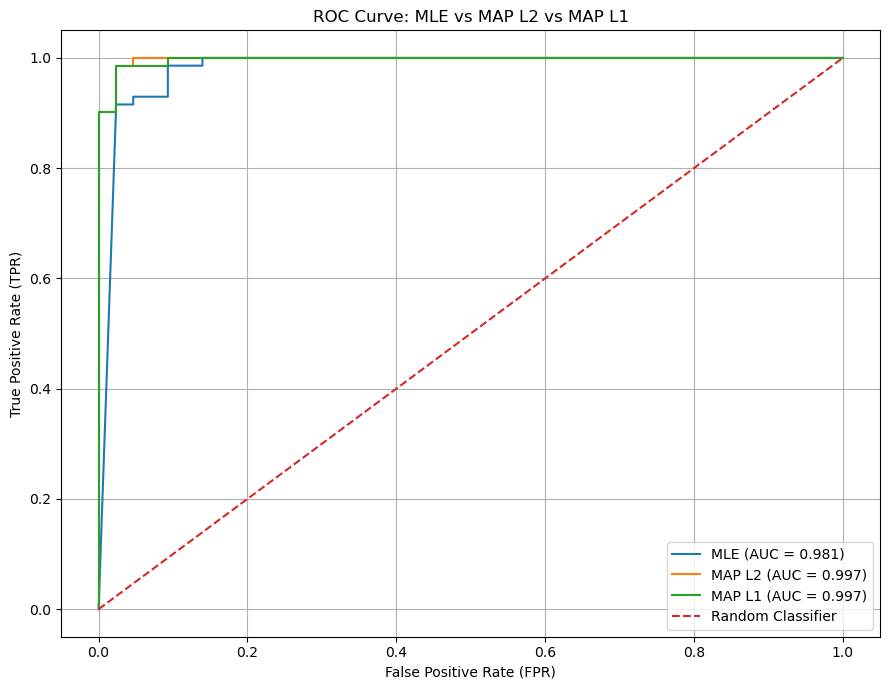

In [39]:
plt.figure(figsize=(9,7))

for name,model, pred in models:

    #Predicted probability for positive class
    y_prob = model.predict_proba(X_test)[:,1]

    #Calculate ROC values
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    #Calculate AUC
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )
    
#Random classsifier reference line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Classifier"
)

#Zoom into the useful region
#plt.xlim(0,0.15)
#plt.ylim(0.75,1.01)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve: MLE vs MAP L2 vs MAP L1")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
